In [1]:
import sys
sys.path.append("C:/Data_Analysis/Projects/football_analytics_dashboard/backend/src")

from player_analytics import *

In [2]:
import pandas as pd

In [3]:
match_id = 3869685

events = pd.read_json(
    f"C:/Data_Analysis/Projects/football_analytics_dashboard/backend/data/events/{match_id}.json"
)

events.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,duel,interception,dribble,shot,goalkeeper,ball_recovery,foul_committed,substitution,50_50,bad_behaviour
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,2026-06-19 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,2026-06-19 00:00:00.000,0,0,"{'id': 35, 'name': 'Starting XI'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,2026-06-19 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,2026-06-19 00:00:00.000,0,0,"{'id': 18, 'name': 'Half Start'}",1,"{'id': 779, 'name': 'Argentina'}","{'id': 1, 'name': 'Regular Play'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,2026-06-19 00:00:00.578,0,0,"{'id': 30, 'name': 'Pass'}",2,"{'id': 771, 'name': 'France'}","{'id': 9, 'name': 'From Kick Off'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
events.shape
events.columns.tolist()

['id',
 'index',
 'period',
 'timestamp',
 'minute',
 'second',
 'type',
 'possession',
 'possession_team',
 'play_pattern',
 'team',
 'duration',
 'tactics',
 'related_events',
 'player',
 'position',
 'location',
 'pass',
 'carry',
 'ball_receipt',
 'under_pressure',
 'off_camera',
 'counterpress',
 'block',
 'foul_won',
 'out',
 'clearance',
 'duel',
 'interception',
 'dribble',
 'shot',
 'goalkeeper',
 'ball_recovery',
 'foul_committed',
 'substitution',
 '50_50',
 'bad_behaviour']

In [5]:
events['type'].dropna().apply(
    lambda x: x['name']
).value_counts()

type
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Offside               1
Shield                1
Player On             1
Player Off            1
Name: count, dtype: int64

In [6]:
pass_event = events[
    events['type'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ) == 'Pass'
]

pass_event.iloc[0]

id                              f651a6c4-55e3-4e0f-a178-59414ba83d6a
index                                                              5
period                                                             1
timestamp                                 2026-06-19 00:00:00.578000
minute                                                             0
second                                                             0
type                                      {'id': 30, 'name': 'Pass'}
possession                                                         2
possession_team                        {'id': 771, 'name': 'France'}
play_pattern                      {'id': 9, 'name': 'From Kick Off'}
team                                   {'id': 771, 'name': 'France'}
duration                                                    0.975702
tactics                                                          NaN
related_events                [97b5dc82-547a-4f93-a632-a2a8daf5ac98]
player                     {'id': 

In [7]:
players = events['player'].dropna().apply(
    lambda x: x['name']
)

players.unique()

array(['Antoine Griezmann', 'Aurélien Djani Tchouaméni', 'Olivier Giroud',
       'Nahuel Molina Lucero', 'Adrien Rabiot', 'Rodrigo Javier De Paul',
       'Cristian Gabriel Romero', 'Nicolás Hernán Otamendi',
       'Ousmane Dembélé', 'Nicolás Alejandro Tagliafico',
       'Alexis Mac Allister', 'Damián Emiliano Martínez',
       'Theo Bernard François Hernández', 'Raphaël Varane',
       'Jules Koundé', 'Lionel Andrés Messi Cuccittini',
       'Ángel Fabián Di María Hernández', 'Julián Álvarez', 'Hugo Lloris',
       'Dayotchanculle Upamecano', 'Enzo Fernandez',
       'Kylian Mbappé Lottin', 'Randal Kolo Muani', 'Marcus Thuram',
       'Marcos Javier Acuña', 'Kingsley Coman', 'Eduardo Camavinga',
       'Gonzalo Ariel Montiel', 'Youssouf Fofana',
       'Lautaro Javier Martínez', 'Leandro Daniel Paredes',
       'Ibrahima Konaté', 'Paulo Bruno Exequiel Dybala',
       'Germán Alejandro Pezzella'], dtype=object)

In [8]:
events['player'].dropna().apply(
    lambda x: x['name']
).value_counts().head(30)

player
Enzo Fernandez                     328
Lionel Andrés Messi Cuccittini     242
Rodrigo Javier De Paul             242
Nicolás Hernán Otamendi            215
Jules Koundé                       211
Aurélien Djani Tchouaméni          205
Cristian Gabriel Romero            203
Dayotchanculle Upamecano           198
Alexis Mac Allister                196
Raphaël Varane                     182
Adrien Rabiot                      176
Nicolás Alejandro Tagliafico       165
Julián Álvarez                     150
Kylian Mbappé Lottin               149
Theo Bernard François Hernández    145
Nahuel Molina Lucero               142
Ángel Fabián Di María Hernández    132
Randal Kolo Muani                  127
Marcus Thuram                      119
Marcos Javier Acuña                112
Antoine Griezmann                  103
Hugo Lloris                         97
Kingsley Coman                      85
Damián Emiliano Martínez            83
Eduardo Camavinga                   83
Gonzalo Ariel Mont

In [9]:
messi_events = events[
    events['player'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ) == 'Lionel Andrés Messi Cuccittini'
]

messi_events.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,duel,interception,dribble,shot,goalkeeper,ball_recovery,foul_committed,substitution,50_50,bad_behaviour
84,9db8a4ba-d842-4f33-9602-90284aa4391e,85,1,2026-06-19 00:02:16.013,2,16,"{'id': 42, 'name': 'Ball Receipt*'}",8,"{'id': 779, 'name': 'Argentina'}","{'id': 4, 'name': 'From Throw In'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,935dedc1-2acb-4f29-b202-c161f926d3ab,86,1,2026-06-19 00:02:16.013,2,16,"{'id': 43, 'name': 'Carry'}",8,"{'id': 779, 'name': 'Argentina'}","{'id': 4, 'name': 'From Throw In'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,1552304a-f3c0-42bf-b7ff-d7b0173d7488,88,1,2026-06-19 00:02:16.985,2,16,"{'id': 30, 'name': 'Pass'}",8,"{'id': 779, 'name': 'Argentina'}","{'id': 4, 'name': 'From Throw In'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,39f56754-50df-4e8b-b454-dcd8a2464caf,96,1,2026-06-19 00:02:26.502,2,26,"{'id': 42, 'name': 'Ball Receipt*'}",8,"{'id': 779, 'name': 'Argentina'}","{'id': 4, 'name': 'From Throw In'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,d8a3bdec-ec1c-42b3-9bbd-943d941ae344,97,1,2026-06-19 00:02:26.502,2,26,"{'id': 43, 'name': 'Carry'}",8,"{'id': 779, 'name': 'Argentina'}","{'id': 4, 'name': 'From Throw In'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
messi_events['type'].apply(
    lambda x: x['name'] if pd.notnull(x) else None
).value_counts()

type
Ball Receipt*      74
Pass               60
Carry              53
Pressure           17
Ball Recovery       7
Dispossessed        6
Shot                6
Miscontrol          3
Dribble             3
Duel                3
Foul Committed      2
Foul Won            2
Injury Stoppage     1
Player Off          1
Player On           1
Offside             1
Clearance           1
Block               1
Name: count, dtype: int64

In [11]:
messi_passes = messi_events[
    messi_events['type'].apply(
        lambda x: x['name']
    ) == 'Pass'
]

len(messi_passes)

60

In [12]:
messi_shots = messi_events[
    messi_events['type'].apply(
        lambda x: x['name']
    ) == 'Shot'
]

len(messi_shots)

6

In [13]:
messi_carries = messi_events[
    messi_events['type'].apply(
        lambda x: x['name']
    ) == 'Carry'
]

len(messi_carries)

53

In [14]:
player_stats = {
    'Player': 'Lionel Messi',
    'Total Events': len(messi_events),
    'Passes': len(messi_passes),
    'Shots': len(messi_shots),
    'Carries': len(messi_carries)
}

player_stats

{'Player': 'Lionel Messi',
 'Total Events': 242,
 'Passes': 60,
 'Shots': 6,
 'Carries': 53}

In [15]:
def get_player_stats(events, player_name):  #events dataframe

    player_events = events[
        events['player'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == player_name
    ]

    event_counts = player_events['type'].apply(
        lambda x: x['name'] if pd.notnull(x) else None
    ).value_counts()

    stats = {
        'Player': player_name,
        'Total Events': int(len(player_events)),
        'Passes': int(event_counts.get('Pass', 0)),
        'Shots': int(event_counts.get('Shot', 0)),
        'Carries': int(event_counts.get('Carry', 0)),
        'Dribbles': int(event_counts.get('Dribble', 0)),
        'Pressures': int(event_counts.get('Pressure', 0)),
        'Ball Recoveries': int(event_counts.get('Ball Recovery', 0))
    }

    return stats

In [16]:
messi_stats = get_player_stats(
    events,
    'Lionel Andrés Messi Cuccittini'
)

print(messi_stats)

{'Player': 'Lionel Andrés Messi Cuccittini', 'Total Events': 242, 'Passes': 60, 'Shots': 6, 'Carries': 53, 'Dribbles': 3, 'Pressures': 17, 'Ball Recoveries': 7}


In [17]:
stats_df = pd.DataFrame([messi_stats])
stats_df

,Player,Total Events,Passes,Shots,Carries,Dribbles,Pressures,Ball Recoveries
0,Lionel Andrés Messi Cuccittini,242,60,6,53,3,17,7


In [18]:
def get_player_locations(events, player_name):

    player_events = events[
        events['player'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == player_name
    ]

    locations = player_events['location'].dropna()

    x = locations.apply(lambda loc: loc[0])
    y = locations.apply(lambda loc: loc[1])

    return x, y

In [19]:
x, y = get_player_locations(
    events,
    'Lionel Andrés Messi Cuccittini'
)

print(len(x))
print(x.head())
print(y.head())

239
84     77.5
85     77.5
87     76.6
95    100.4
96    100.4
Name: location, dtype: float64
84    36.9
85    36.9
87    35.7
95    57.7
96    57.7
Name: location, dtype: float64


In [20]:
x, y = get_player_locations(
    events,
    'Lionel Andrés Messi Cuccittini'
)

coords = pd.DataFrame({
    'x': x,
    'y': y
})

coords.head()

,x,y
84,77.5,36.9
85,77.5,36.9
87,76.6,35.7
95,100.4,57.7
96,100.4,57.7


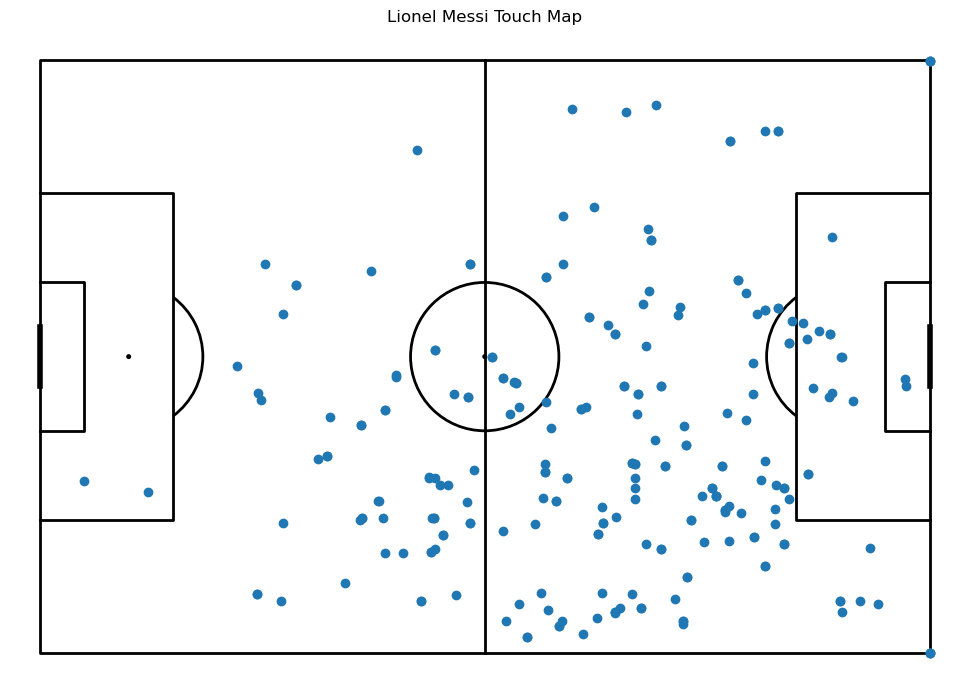

In [21]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black'
)

fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(
    x,
    y,
    ax=ax
)

plt.title("Lionel Messi Touch Map")
plt.show()

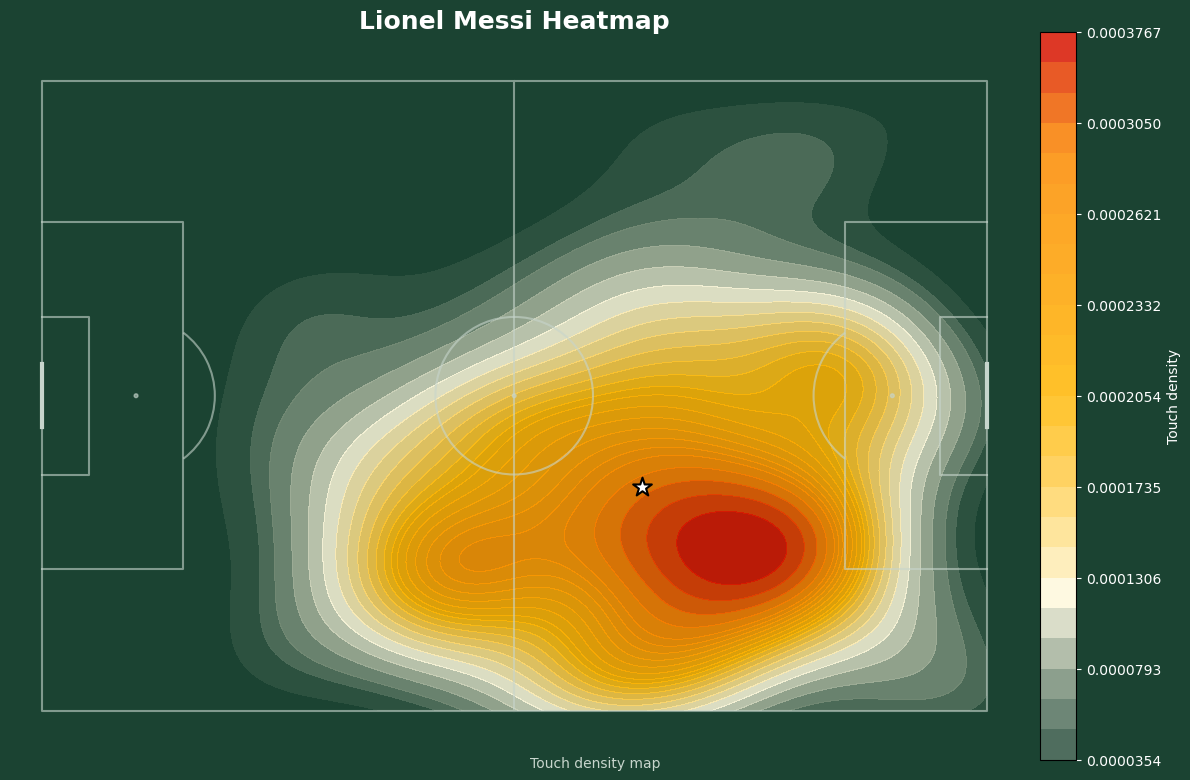

In [22]:
import numpy as np
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

heatmap_colors = LinearSegmentedColormap.from_list(
    "custom_heatmap",
    ['#1B4332', '#fefae0', '#ffb703', '#fb8500', '#d00000']
)

# stripe=False avoids the banding artifact — stripes were being drawn
# as separate patches that interfered with the kdeplot's alpha blending
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#1B4332',
    line_color='#c7d5cc',
    linewidth=1.5,
    line_alpha=0.6,
    stripe=False
)

fig, ax = pitch.draw(figsize=(12, 8))

kde = pitch.kdeplot(
    x=x,
    y=y,
    fill=True,
    levels=25,
    thresh=0.05,
    bw_adjust=1.0,
    cmap=heatmap_colors,
    alpha=0.85,
    zorder=0.5,   # heatmap sits above the flat pitch_color, below the lines
    ax=ax
)

cbar = fig.colorbar(kde.collections[0] if hasattr(kde, 'collections') else kde,
                     ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Touch density', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

avg_x, avg_y = np.mean(x), np.mean(y)
pitch.scatter(avg_x, avg_y, s=200, color='white', edgecolors='black',
              linewidth=1.5, zorder=3, ax=ax, marker='*')

fig.set_facecolor('#1B4332')
ax.set_facecolor('#1B4332')

plt.title("Lionel Messi Heatmap", color="white", fontsize=18, fontweight='bold', pad=15)
plt.figtext(0.5, 0.02, "Touch density map", color="#c7d5cc", fontsize=10, ha='center')

plt.tight_layout()
plt.show()

In [23]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import pandas as pd

def plot_player_heatmap(events, player_name):

    # Filter player events
    player_events = events[
        events['player'].apply(
            lambda x: x['name'] if pd.notnull(x) else None
        ) == player_name
    ]

    # Extract locations
    locations = player_events['location'].dropna()

    x = locations.apply(lambda loc: loc[0])
    y = locations.apply(lambda loc: loc[1])

    # Custom heatmap colors
    heatmap_colors = LinearSegmentedColormap.from_list(
        "custom_heatmap",
        [
            '#fefae0',  # cream
            '#ffb703',  # yellow
            '#fb8500',  # orange
            '#d00000'   # red
        ]
    )

    # Create pitch
    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color='#1B4332',
        line_color='white',
        linewidth=2
    )

    fig, ax = pitch.draw(figsize=(12, 8))

    # Smooth heatmap
    pitch.kdeplot(
        x=x,
        y=y,
        fill=True,
        levels=100,
        thresh=0.05,
        bw_adjust=0.7,
        cmap=heatmap_colors,
        alpha=0.9,
        ax=ax
    )

    # Optional touch points
    pitch.scatter(
        x,
        y,
        s=15,
        color='white',
        alpha=0.15,
        ax=ax
    )

    # Styling
    fig.set_facecolor('#1B4332')
    ax.set_facecolor('#1B4332')

    ax.set_title(
        f"{player_name} Heatmap",
        color='white',
        fontsize=18,
        pad=20,
        fontweight='bold'
    )

    return fig

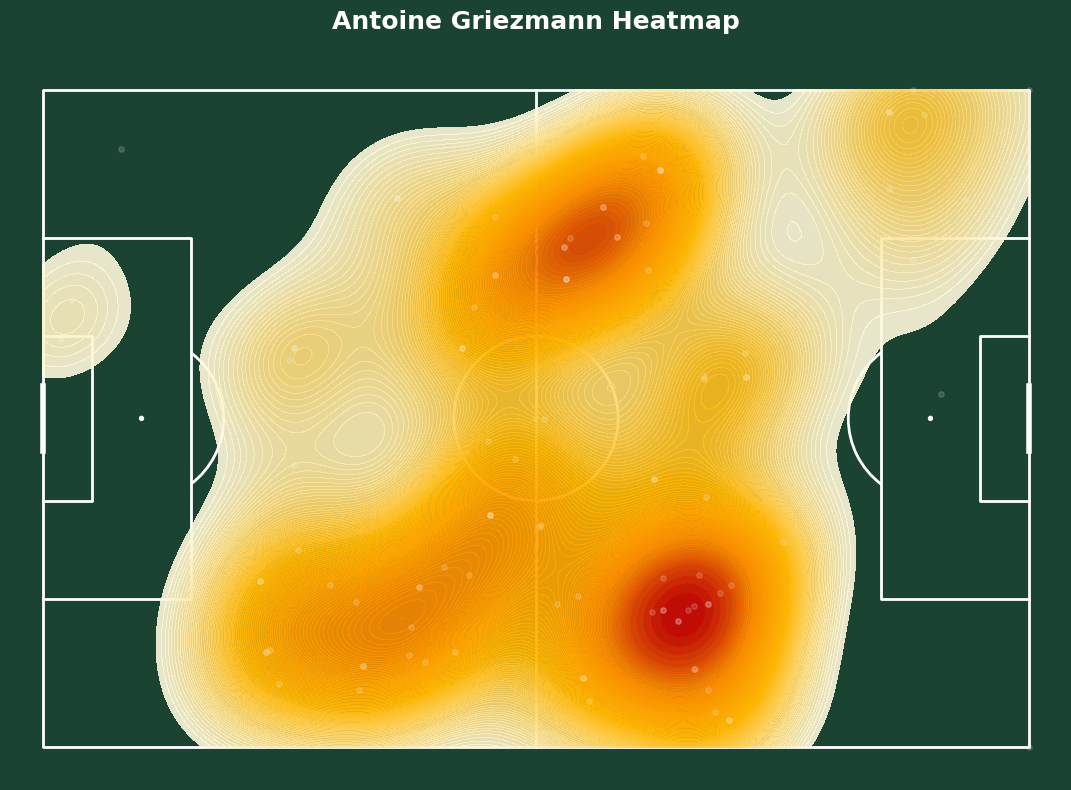

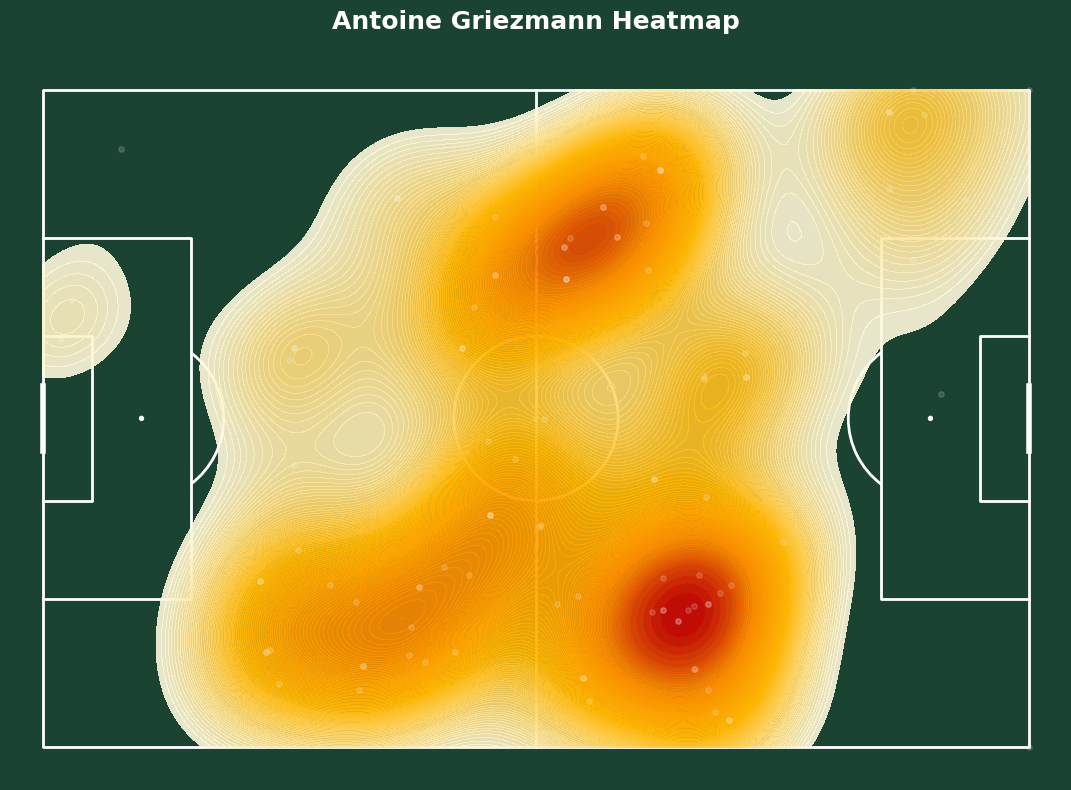

In [24]:
plot_player_heatmap(
    events,
    'Antoine Griezmann'
)